In [42]:
import pandas as pd
import numpy as np
import seaborn as sns

In [43]:
df = pd.read_csv("/Users/apple/Desktop/AI-ML/Datasets/weight-height.csv")

In [44]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [45]:
df.shape

(10000, 3)

In [46]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

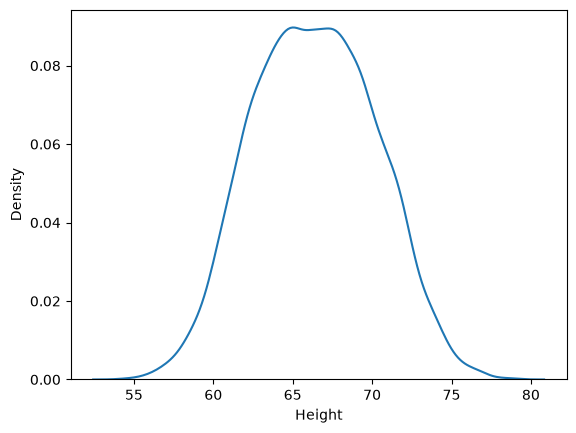

In [47]:
sns.kdeplot(df['Height'])

<Axes: xlabel='Height'>

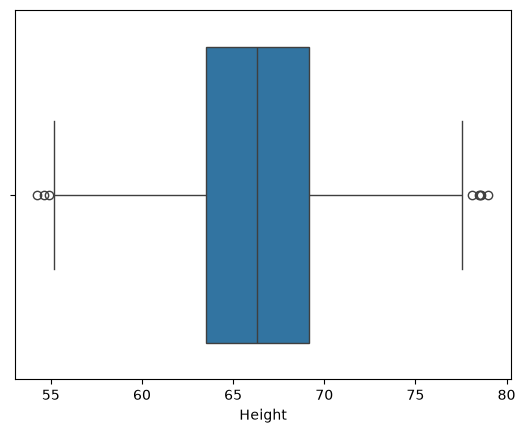

In [48]:
sns.boxplot(x=df['Height'])

In [49]:
upper_limit = df['Height'].quantile(0.999)
upper_limit

np.float64(77.06738853278372)

In [50]:
lower_limit = df['Height'].quantile(0.001)
lower_limit

np.float64(56.06654891162125)

In [51]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [52]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

In [53]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

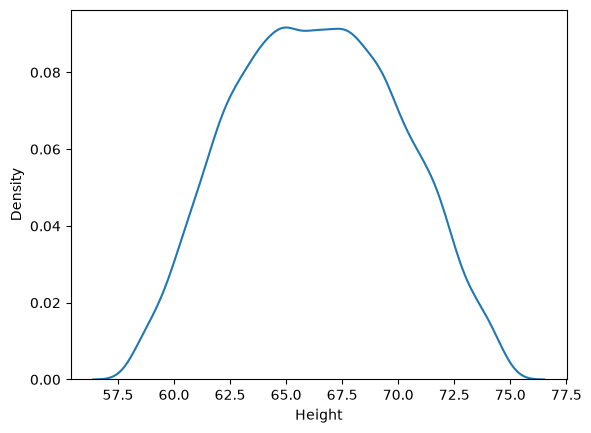

In [54]:
sns.kdeplot(new_df['Height'])

<Axes: xlabel='Height'>

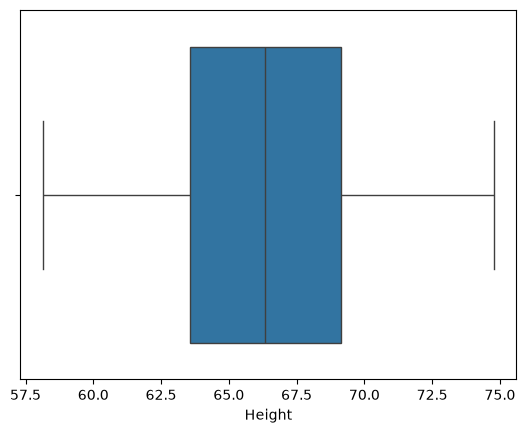

In [55]:
sns.boxplot(x=new_df['Height'])

In [ ]:
# Capping --> Winsorization
new_df_cap = df.copy()

new_df_cap['Height'] = np.where(
    df['Height']>=upper_limit,
    upper_limit,
    np.where(
        df['Height']<=lower_limit,
        lower_limit,
        df['Height']
    )
)

In [58]:
new_df_cap.shape

(10000, 3)

In [59]:
new_df_cap.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367438,161.440357
std,3.842807,32.108439
min,56.066549,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,77.067389,269.989699


<Axes: xlabel='Height', ylabel='Density'>

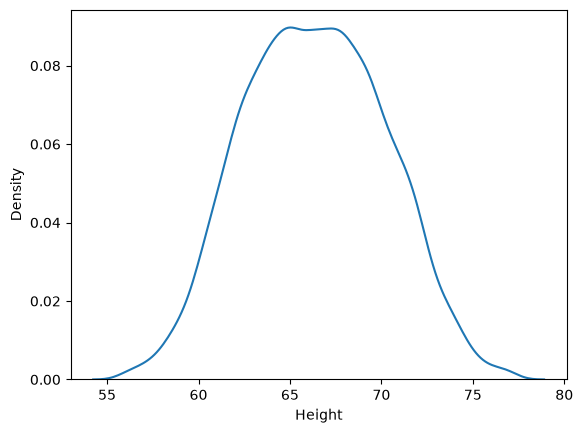

In [60]:
sns.kdeplot(new_df_cap['Height'])

<Axes: xlabel='Height'>

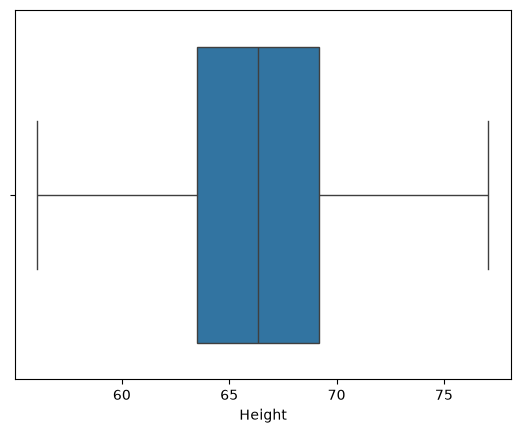

In [61]:
sns.boxplot(x=new_df_cap['Height'])